# COP9517 lab04 Han Qin z5565186
### Steps
- Convert the input image to grayscale and apply Otsu intensity thresholding.
- Next, use opening and closing operators to filter out noise and fill holes in the segmentation,
- identify connected components 
- and use reconstruction operations to get rid of segmented objects touching the image boundary, remove objects that are smaller than a certain size, 
- and then count and print the final number of objects. 

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

- Helper Function showcase all the steps

In [44]:
def show_steps(name, images):
    titles = [
        "Original",
        "Grayscale",
        "Otsu threshold",
        "After opening",
        "After closing",
        "Remove border objects",
        "Final segmentation",
    ]

    fig, axes = plt.subplots(1, len(images), figsize=(22, 4))

    for ax, title, image in zip(axes, titles, images):
        if len(image.shape) == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)

        ax.set_title(title, fontsize=11)
        ax.axis("off")

    fig.suptitle(name, fontsize=16, weight="bold")
    plt.tight_layout()
    plt.show()

In [45]:
def remove_border_objects(binary, kernel):
    """
    helper function remove border object using operation in lecture note
    """
    marker = np.zeros_like(binary)

    marker[0, :] = binary[0, :]
    marker[-1, :] = binary[-1, :]
    marker[:, 0] = binary[:, 0]
    marker[:, -1] = binary[:, -1]

    previous = np.zeros_like(marker)
    current = marker.copy()

    while not np.array_equal(current, previous):
        previous = current.copy()
        dilated = cv.dilate(current, kernel, iterations=1)
        current = cv.bitwise_and(dilated, binary)

    return cv.subtract(binary, current)

def segment_and_count(image_path, invert=False, kernel_size=10, min_area=2000):
    """
    helper function apply otsu thresholding, and then open close,
    and find the connected components, finally remove object smaller
    then certain area.
    """
    img_bgr = cv.imread(image_path)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    _, binary = cv.threshold(
        gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
    )

    if invert:
        binary = cv.bitwise_not(binary)

    kernel = cv.getStructuringElement(
        cv.MORPH_ELLIPSE, (kernel_size, kernel_size)
    )

    opened = cv.morphologyEx(binary, cv.MORPH_OPEN, kernel)
    closed = cv.morphologyEx(opened, cv.MORPH_CLOSE, kernel)

    no_border = remove_border_objects(closed, kernel)

    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(
        no_border, connectivity=8
    )

    output = np.zeros_like(no_border)
    count = 0

    for label in range(1, num_labels):
        area = stats[label, cv.CC_STAT_AREA]
        if area > min_area:
            output[labels == label] = 255
            count += 1

    steps = [
        img_rgb,
        gray,
        binary,
        opened,
        closed,
        no_border,
        output,
    ]

    return img_rgb, output, count, steps

### Tuple Parameter 
- `name`, `filename` stands for the target image and its content
- `invert` Ture if the object is considered 'dark'(black) part, revert the 1, 0 setting for if Ture
- `kernel_size` for the open-close operation 
- `min_area` the area threshold, remove the object if area < min_area

In [46]:
image_dir = "image"

configs = [
    {
        "name": "Fruits",
        "filename": "Fruits.jpg",
        "invert": True,
        "kernel_size": 10,
        "min_area": 2000,
    },
    {
        "name": "Pineapples",
        "filename": "Pineapples.jpg",
        "invert": False,
        "kernel_size": 10,
        "min_area": 2000,
    },
    {
        "name": "Monsters",
        "filename": "Monsters.jpg",
        "invert": False,
        "kernel_size": 10,
        "min_area": 2000,
    },
]

### Main function that call every step and count number of components

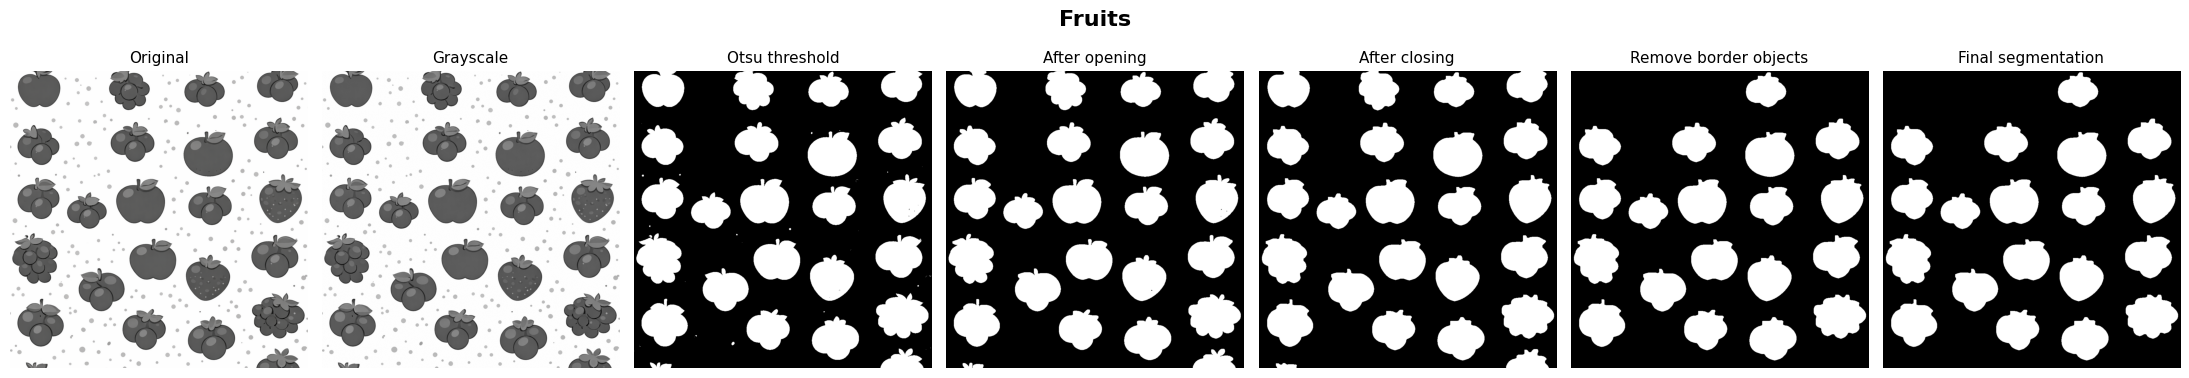

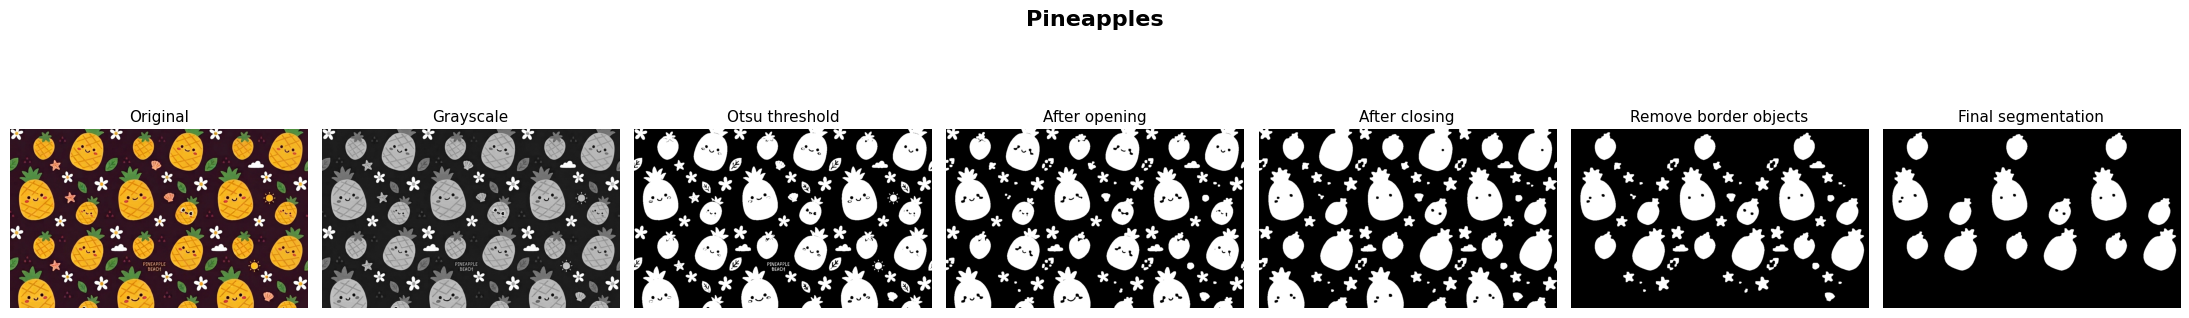

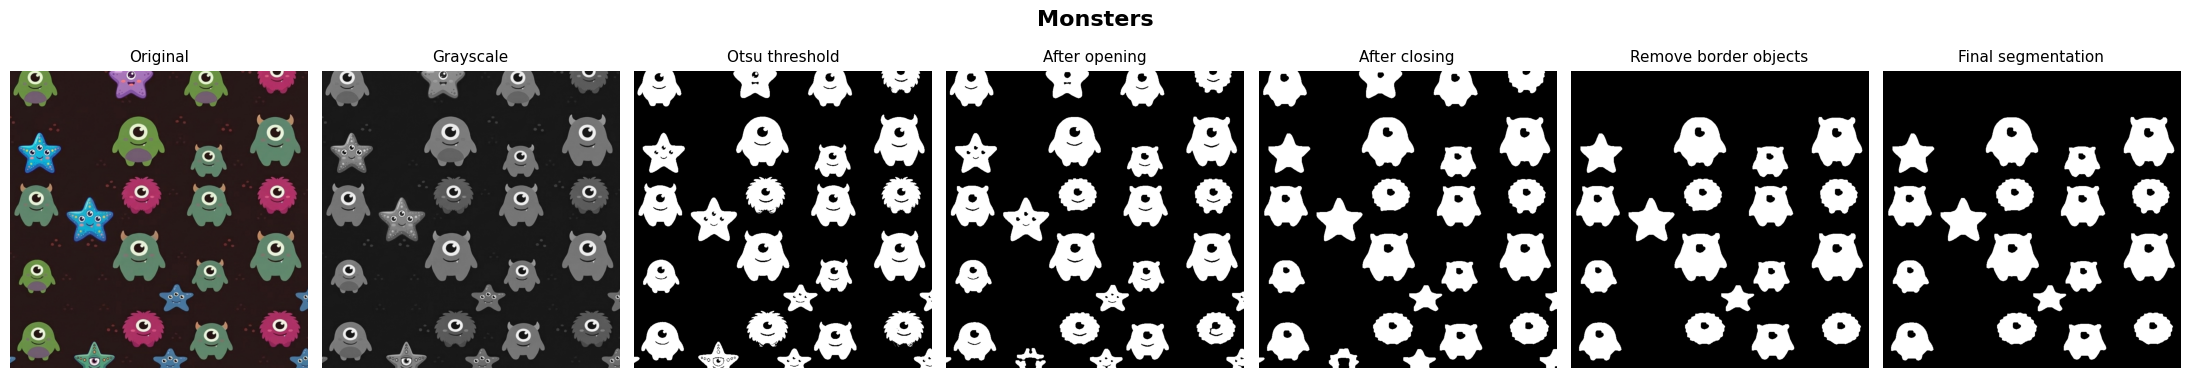

In [47]:


results = []

for config in configs:
    image_path = os.path.join(image_dir, config["filename"])

    img_rgb, segmentation, count, steps = segment_and_count(
    image_path,
    invert=config["invert"],
    kernel_size=config["kernel_size"],
    min_area=config["min_area"],
    )

    show_steps(config["name"], steps)

    results.append((config["name"], img_rgb, segmentation, count))


### Show the final object count

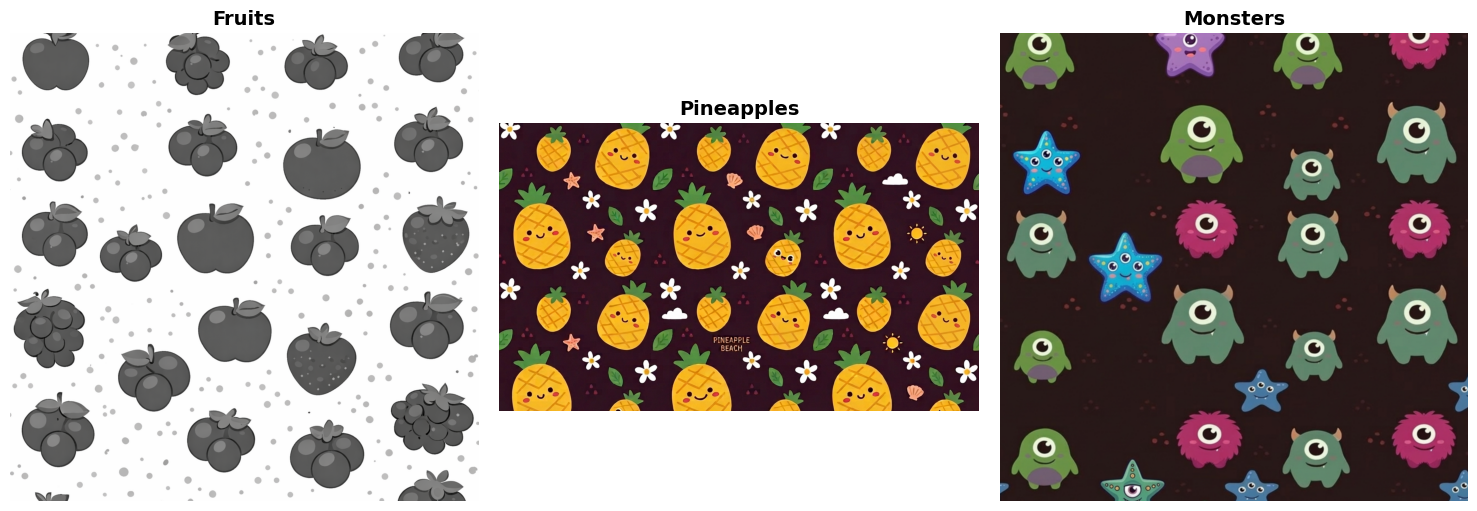

Fruits: n = 19
Pineapples: n = 15
Monsters: n = 18


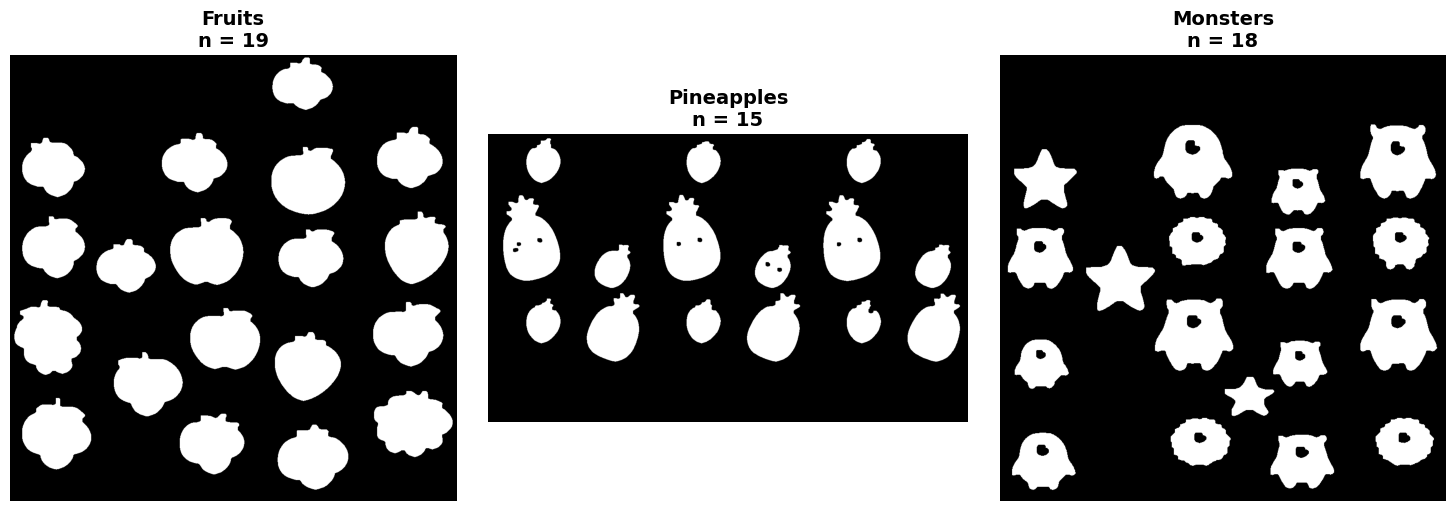

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, img_rgb, _, _) in zip(axes, results):
    ax.imshow(img_rgb)
    ax.set_title(name, fontsize=14, weight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, _, segmentation, count) in zip(axes, results):
    ax.imshow(segmentation, cmap="gray")
    ax.set_title(f"{name}\nn = {count}", fontsize=14, weight="bold")
    ax.axis("off")

    print(f"{name}: n = {count}")

plt.tight_layout()
plt.show()